# Prophet — Seasonality & Holidays
Everything you need to model periodic patterns and known events.

**Topics covered:**
1. Built-in yearly / weekly / daily seasonality
2. Additive vs multiplicative modes
3. Custom seasonalities (monthly, quarterly)
4. Conditional seasonalities (on-season / off-season)
5. Custom holiday table
6. Country-level public holidays
7. Side-by-side comparison


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

df = pd.read_csv(
    "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
)
df["ds"] = pd.to_datetime(df["ds"])
print(f"Rows: {len(df)}  |  {df['ds'].min().date()} → {df['ds'].max().date()}")

Rows: 2905  |  2007-12-10 → 2016-01-20


## 1. Additive vs Multiplicative Seasonality

| Mode | Formula | Use when |
|------|---------|---------|
| `additive` | trend + seasonality | Seasonal swings are **constant** in absolute size |
| `multiplicative` | trend × seasonality | Seasonal swings **scale** with the trend level |

Most business metrics (revenue, page-views) scale → use `multiplicative`.

08:18:00 - cmdstanpy - INFO - Chain [1] start processing


08:18:01 - cmdstanpy - INFO - Chain [1] done processing


08:18:03 - cmdstanpy - INFO - Chain [1] start processing


08:18:04 - cmdstanpy - INFO - Chain [1] done processing


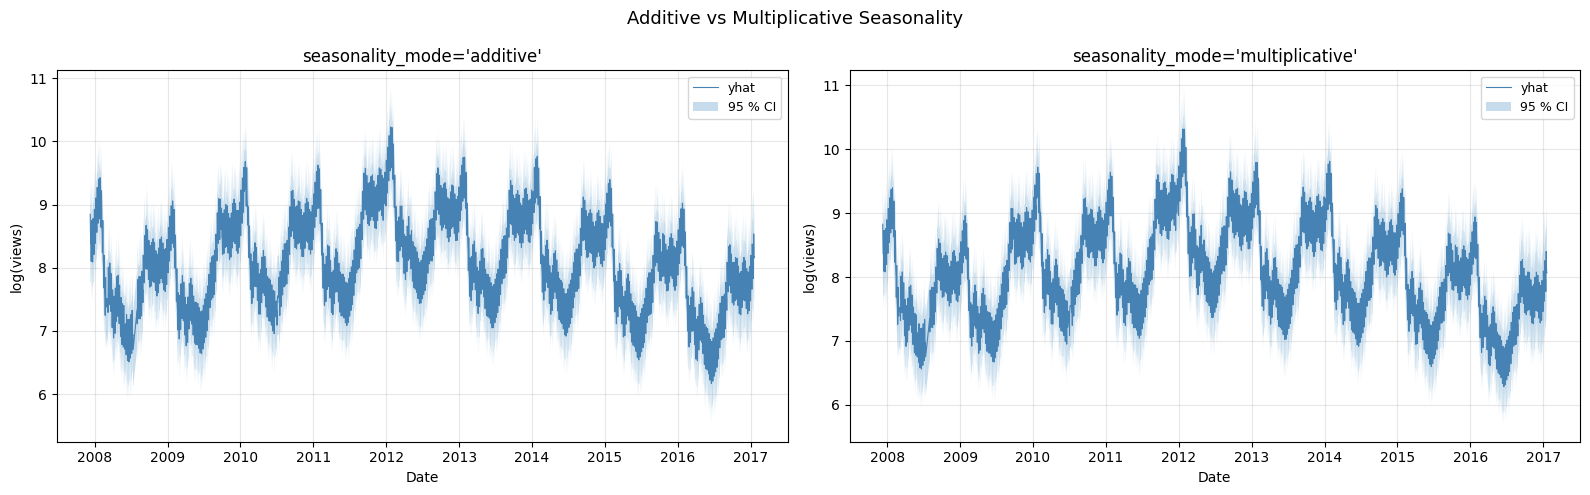

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, mode in zip(axes, ["additive", "multiplicative"]):
    m = Prophet(seasonality_mode=mode, yearly_seasonality=True, weekly_seasonality=True)
    m.fit(df)
    fc = m.predict(m.make_future_dataframe(periods=365))
    ax.plot(fc["ds"], fc["yhat"], label="yhat", color="steelblue", linewidth=0.8)
    ax.fill_between(fc["ds"], fc["yhat_lower"], fc["yhat_upper"], alpha=0.25, label="95 % CI")
    ax.set_title(f"seasonality_mode='{mode}'")
    ax.set_xlabel("Date"); ax.set_ylabel("log(views)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("Additive vs Multiplicative Seasonality", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Fourier Order — Shape vs Complexity
Each seasonality is a Fourier series. Higher `fourier_order` → more complex curve.

```
s(t) = Σ [aₙ cos(2πnt/P) + bₙ sin(2πnt/P)]   n = 1..N
```

Pass an integer directly to `yearly_seasonality` / `weekly_seasonality` to set $N$.

08:18:10 - cmdstanpy - INFO - Chain [1] start processing


08:18:11 - cmdstanpy - INFO - Chain [1] done processing


08:18:12 - cmdstanpy - INFO - Chain [1] start processing


08:18:13 - cmdstanpy - INFO - Chain [1] done processing


08:18:13 - cmdstanpy - INFO - Chain [1] start processing


08:18:14 - cmdstanpy - INFO - Chain [1] done processing


08:18:15 - cmdstanpy - INFO - Chain [1] start processing


08:18:16 - cmdstanpy - INFO - Chain [1] done processing


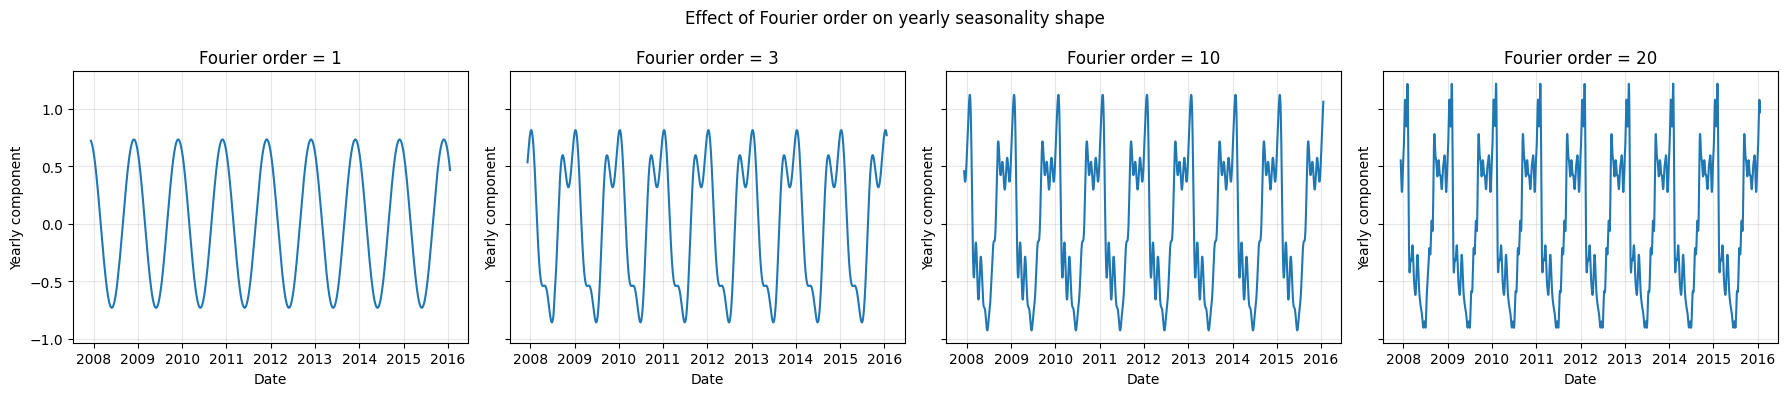

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, fo in zip(axes, [1, 3, 10, 20]):
    m = Prophet(yearly_seasonality=fo, weekly_seasonality=False, daily_seasonality=False)
    m.fit(df)
    fc = m.predict(m.make_future_dataframe(periods=0, include_history=True))
    yr = fc[["ds","yearly"]].set_index("ds")
    ax.plot(yr.index, yr["yearly"])
    ax.set_title(f"Fourier order = {fo}")
    ax.set_xlabel("Date"); ax.set_ylabel("Yearly component"); ax.grid(True, alpha=0.3)

plt.suptitle("Effect of Fourier order on yearly seasonality shape", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Custom Seasonalities
Add any periodic pattern not covered by the built-ins.

08:18:17 - cmdstanpy - INFO - Chain [1] start processing


08:18:18 - cmdstanpy - INFO - Chain [1] done processing


/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a

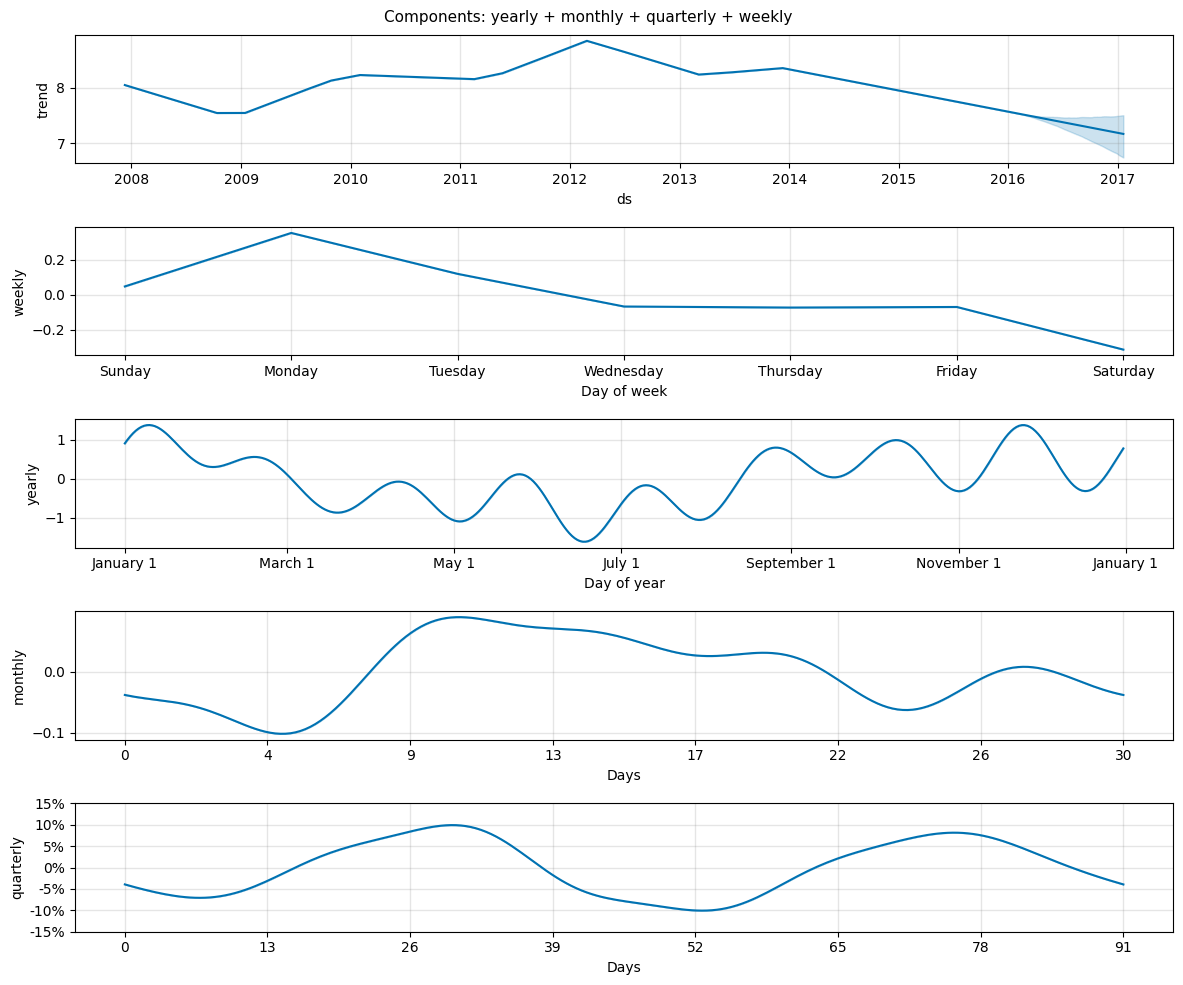

In [4]:
m_custom = Prophet(yearly_seasonality=True, weekly_seasonality=False)

# Monthly pattern (~30.5-day cycle)
m_custom.add_seasonality(name="monthly",   period=30.5,  fourier_order=5)
# Quarterly pattern
m_custom.add_seasonality(name="quarterly", period=91.25, fourier_order=7, mode="multiplicative")
# Custom weekly
m_custom.add_seasonality(name="weekly",    period=7,     fourier_order=3)

m_custom.fit(df)
fc_custom = m_custom.predict(m_custom.make_future_dataframe(periods=365))

fig = m_custom.plot_components(fc_custom)
fig.set_size_inches(12, 10)
plt.suptitle("Components: yearly + monthly + quarterly + weekly", fontsize=11)
plt.tight_layout()
plt.show()

## 4. Conditional Seasonalities
Apply different seasonal patterns depending on a condition in the data.
Here we fit separate weekly patterns for on-season (Jul–Dec) and off-season (Jan–Jun).

08:18:20 - cmdstanpy - INFO - Chain [1] start processing


08:18:20 - cmdstanpy - INFO - Chain [1] done processing


/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


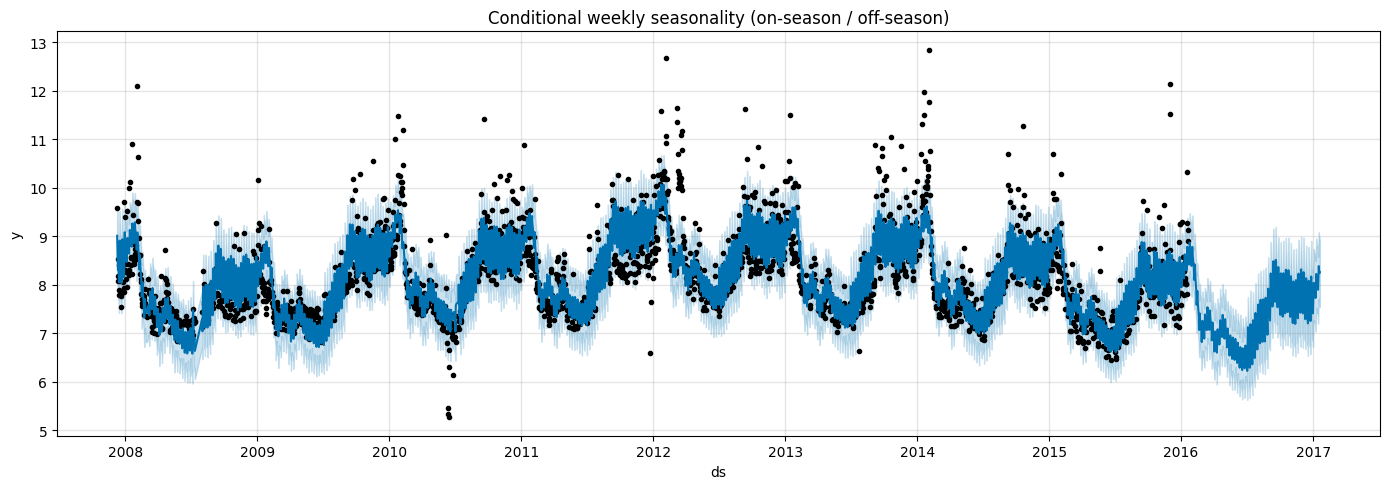

In [5]:
df_cond = df.copy()
df_cond["on_season"]  = (df_cond["ds"].dt.month >= 7).astype(int)
df_cond["off_season"] = 1 - df_cond["on_season"]

m_cond = Prophet(yearly_seasonality=True, weekly_seasonality=False)
m_cond.add_seasonality("weekly_on",  period=7, fourier_order=3, condition_name="on_season")
m_cond.add_seasonality("weekly_off", period=7, fourier_order=3, condition_name="off_season")
m_cond.fit(df_cond)

future_cond = m_cond.make_future_dataframe(periods=365)
future_cond["on_season"]  = (future_cond["ds"].dt.month >= 7).astype(int)
future_cond["off_season"] = 1 - future_cond["on_season"]

fc_cond = m_cond.predict(future_cond)
fig = m_cond.plot(fc_cond)
fig.set_size_inches(14, 5)
plt.title("Conditional weekly seasonality (on-season / off-season)")
plt.tight_layout()
plt.show()

## 5. Custom Holiday Table
Pass a DataFrame with known event dates.
`lower_window` / `upper_window` define how many days before/after the effect extends.

In [6]:
playoffs = pd.DataFrame({
    "holiday": "playoff",
    "ds": pd.to_datetime([
        "2008-01-13","2009-01-03","2010-01-16",
        "2010-01-24","2010-02-07","2011-01-08",
        "2013-01-12","2014-01-12","2014-01-19",
        "2014-02-02","2015-01-11","2016-01-17",
        "2016-01-24","2016-02-07",
    ]),
    "lower_window": 0,
    "upper_window": 1,
})

superbowls = pd.DataFrame({
    "holiday": "superbowl",
    "ds": pd.to_datetime(["2010-02-07","2014-02-02","2016-02-07"]),
    "lower_window": 0,
    "upper_window": 1,
})

holidays = pd.concat([playoffs, superbowls], ignore_index=True)
print(holidays)

      holiday         ds  lower_window  upper_window
0     playoff 2008-01-13             0             1
1     playoff 2009-01-03             0             1
2     playoff 2010-01-16             0             1
3     playoff 2010-01-24             0             1
4     playoff 2010-02-07             0             1
5     playoff 2011-01-08             0             1
6     playoff 2013-01-12             0             1
7     playoff 2014-01-12             0             1
8     playoff 2014-01-19             0             1
9     playoff 2014-02-02             0             1
10    playoff 2015-01-11             0             1
11    playoff 2016-01-17             0             1
12    playoff 2016-01-24             0             1
13    playoff 2016-02-07             0             1
14  superbowl 2010-02-07             0             1
15  superbowl 2014-02-02             0             1
16  superbowl 2016-02-07             0             1


08:18:21 - cmdstanpy - INFO - Chain [1] start processing


08:18:22 - cmdstanpy - INFO - Chain [1] done processing


/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a

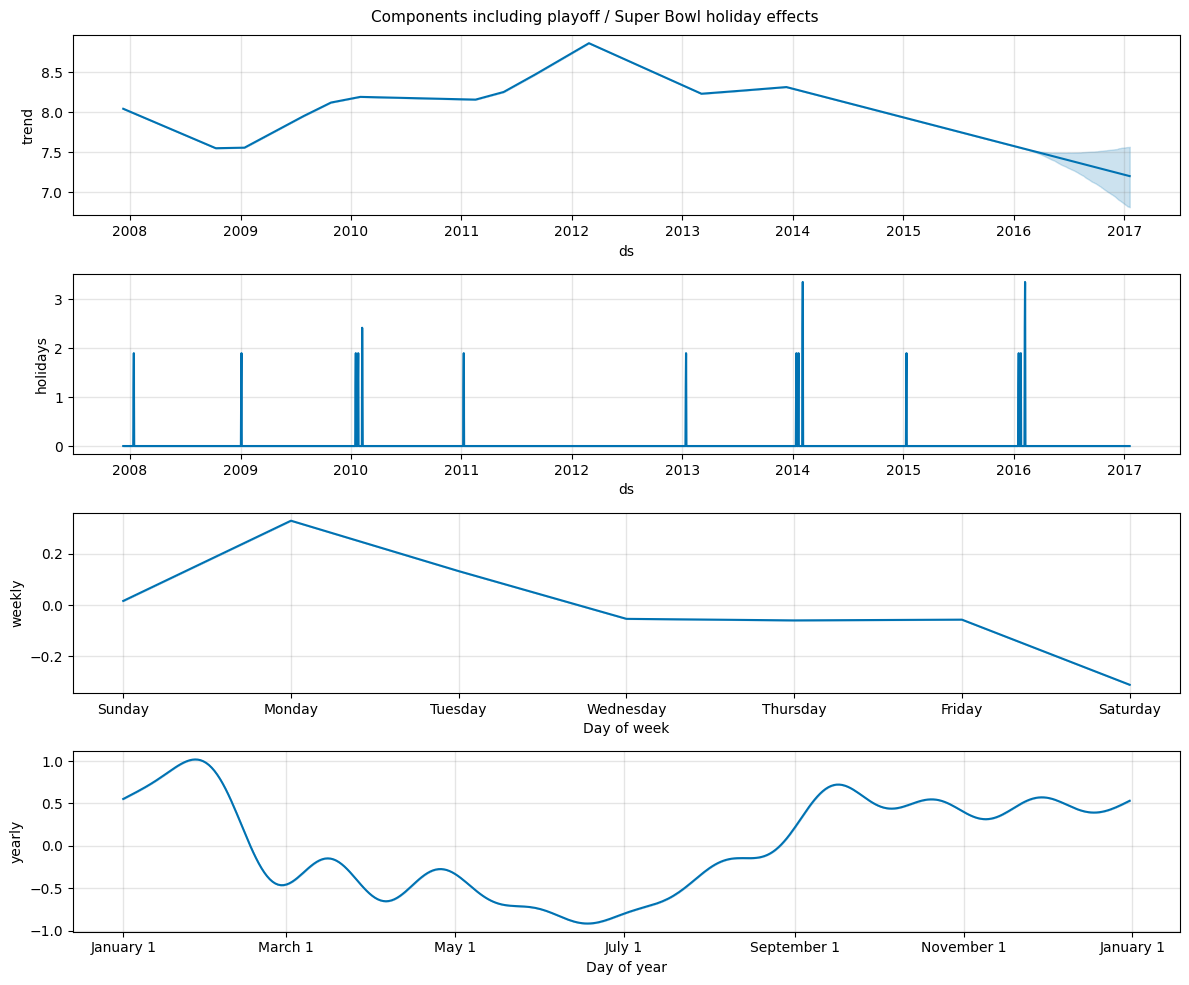

In [7]:
m_hol = Prophet(holidays=holidays, holidays_prior_scale=10.0,
                yearly_seasonality=True, weekly_seasonality=True)
m_hol.fit(df)
fc_hol = m_hol.predict(m_hol.make_future_dataframe(periods=365))

fig = m_hol.plot_components(fc_hol)
fig.set_size_inches(12, 10)
plt.suptitle("Components including playoff / Super Bowl holiday effects", fontsize=11)
plt.tight_layout()
plt.show()

## 6. Country-Level Public Holidays
Prophet can load public holiday calendars for many countries automatically.

In [8]:
m_country = Prophet(yearly_seasonality=True, weekly_seasonality=True)
m_country.add_country_holidays(country_name="US")
m_country.fit(df)

print("Loaded US holidays:")
print(sorted(m_country.train_holiday_names))

08:18:24 - cmdstanpy - INFO - Chain [1] start processing


08:18:24 - cmdstanpy - INFO - Chain [1] done processing


Loaded US holidays:
['Christmas Day', 'Christmas Day (observed)', 'Columbus Day', 'Independence Day', 'Independence Day (observed)', 'Labor Day', 'Martin Luther King Jr. Day', 'Memorial Day', "New Year's Day", "New Year's Day (observed)", 'Thanksgiving', 'Veterans Day', 'Veterans Day (observed)', "Washington's Birthday"]


/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a

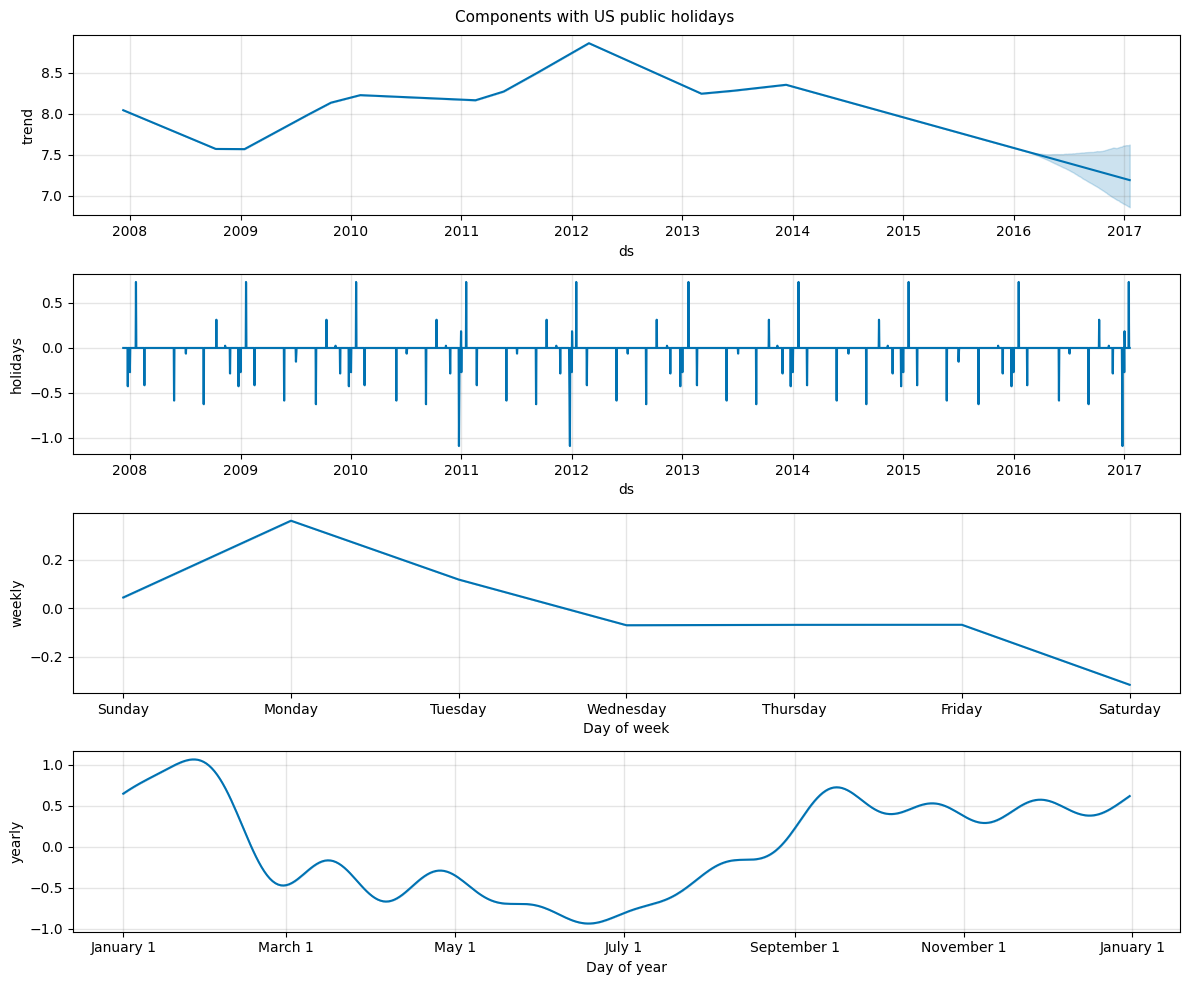

In [9]:
fc_country = m_country.predict(m_country.make_future_dataframe(periods=365))
fig = m_country.plot_components(fc_country)
fig.set_size_inches(12, 10)
plt.suptitle("Components with US public holidays", fontsize=11)
plt.tight_layout()
plt.show()